# Maximum Likelihood Estimation for Earth Interior Evolution

This tutorial demonstrates how to use **maximum likelihood estimation (MLE)** with `vplanet_inference`
to find initial conditions for Earth's thermal interior evolution that are consistent with present-day geophysical observations
used in Gilbert-Janizek et al. (2026): [A whole-planet model of the Earth without life for terrestrial exoplanet studies](https://arxiv.org/abs/2602.02267)

We use VPLanet's `thermint` (thermal interior) and `radheat` (radiogenic heating) modules to model:

- Mantle and core temperature evolution over 4.5 Gyr
- Heat flow from the core-mantle boundary (CMB) and upper mantle surface
- Growth of the inner core radius
- Mantle viscosity from a self-consistent parameterized convection scheme

We then apply MLE to find the combination of planetary parameters that best reproduce the modern Earth. See [Gilbert-Janizek et al. (2026)](https://arxiv.org/abs/2602.02267) for more details.

### What we cover

1. **Earth model setup** — VPLanet infiles for `thermint` + `radheat`, and the `VplanetModel` interface
2. **Observational constraints** — present-day geophysical measurements and the Gaussian log-likelihood
3. **Fiducial model** — verifying the setup by running at known-good parameters
4. **Single optimization** — `scipy.optimize.minimize` with the Nelder-Mead algorithm
5. **Multi-start MLE** — parallel optimization from random starting points to handle non-convexity
6. **Results analysis** — comparing best-fit outputs to observations

---

**Dependencies:** `vplanet_inference`, `scipy`, `numpy`, `matplotlib`, `astropy`, `pandas`, `tqdm`

**VPLanet modules used:** `thermint`, `radheat`, `stellar` (for the host Sun)

**References:**
- [VPLanet documentation](https://virtualplanetarylaboratory.github.io/vplanet/)
- [Driscoll & Barnes (2015)](https://doi.org/10.1017/S1473550415000130) — `thermint` module
- [vplanet_inference GitHub repository](https://github.com/jbirky/vplanet_inference)

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.optimize
import multiprocessing as mp
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from functools import partial
from tqdm import tqdm
import warnings

import vplanet_inference as vpi

warnings.filterwarnings('ignore')

## 1. Earth Model Setup

### 1.1 VPLanet Input Files

The Earth interior model requires three input files:

| File | Purpose |
|------|---------|
| `vpl.in` | System control file — units, timing, list of bodies |
| `sun.in` | Host star — fixed luminosity and mass (no stellar evolution) |
| `earth.in` | Earth body — `radheat` + `thermint` modules, initial conditions |

The `radheat` module tracks the decay of long-lived radiogenic isotopes
(${}^{40}\text{K}$, ${}^{232}\text{Th}$, ${}^{235}\text{U}$, ${}^{238}\text{U}$) and computes their contribution to mantle
and core heating over geological time.

The `thermint` module uses a parameterized convection model to evolve the
mantle and core temperatures, computing heat flows, viscosity, inner core growth,
and magnetic moment self-consistently from the thermal state.

We create the infiles in a local `earth_infiles/` directory so this notebook is self-contained.

In [2]:
INFILE_PATH = "earth_infiles/"
os.makedirs(INFILE_PATH, exist_ok=True)

# SI conversion constants
STOP_TIME_SEC  = (4.5e9 * u.yr).si.value   # 4.5 Gyr in seconds
OUT_TIME_SEC   = (1e8  * u.yr).si.value    # 100 Myr in seconds
M_SUN_KG       = const.M_sun.si.value      # solar mass in kg
R_SUN_0135_M   = (0.00135 * u.AU).si.value # 0.00135 AU in metres
OBL_RAD        = float((23.5 * u.deg).to(u.rad).value)  # obliquity in radians

# ---- vpl.in ----
# Units will be converted to SI by vplanet_inference (sUnitMass->kg, sUnitLength->m,
# sUnitTime->sec, sUnitAngle->rad). dStopTime and dOutputTime are therefore written
# in seconds so VPLanet interprets them correctly after the unit substitution.
vpl_in = f"""\
# Primary input file: Earth interior evolution
sSystemName     earth
iVerbose        0
bOverwrite      1

saBodyFiles     sun.in earth.in

sUnitMass       solar
sUnitLength     aU
sUnitTime       YEARS
sUnitAngle      d
sUnitTemp       K

bDoLog          1
iDigits         6
dMinValue       1e-10

bDoForward      1
bVarDt          1
dEta            0.1
dStopTime       {STOP_TIME_SEC:.6e}
dOutputTime     {OUT_TIME_SEC:.6e}
"""

# ---- sun.in ----
# All values in SI because vplanet_inference sets sUnitMass=kg, sUnitLength=m.
sun_in = f"""\
# Host star: present-day Sun (fixed, no evolution)
sName           sun
saModules       stellar
dMass           {M_SUN_KG:.6e}
dRadius         {R_SUN_0135_M:.6e}
dLuminosity     3.846e26
dSemi           0
dEcc            0
sStellarModel   none
"""

# ---- earth.in ----
# dObliquity in radians (vplanet_inference sets sUnitAngle=rad).
# Negative values (-1) tell VPLanet to use its built-in Earth defaults.
earth_in = f"""\
# Earth body: radiogenic heating + thermal interior
sName           earth
saModules       radheat thermint

# Physical properties (negative -> VPLanet Earth defaults, unit-independent)
dMass           -1.0
dRadius         -1.0
dRotPeriod      -1.0
dObliquity      {OBL_RAD:.6f}
dRadGyra        0.5
dEcc            0.0167
dSemi           -1

# Radiogenic heating — 40K (substituted by vplanet_inference)
d40KPowerMan    -1
d40KPowerCore   -1
d40KPowerCrust  -1

# Radiogenic heating — other isotopes (default Earth values)
d232ThPowerMan    -1
d232ThPowerCore   -1
d232ThPowerCrust  -1
d235UPowerMan     -1
d235UPowerCore    -1
d235UPowerCrust   -1
d238UPowerMan     -1
d238UPowerCore    -1
d238UPowerCrust   -1

# Thermint initial conditions and rheological parameters
dTMan           3000
dTCore          6500
dViscJumpMan    2.4
dActViscMan     3e5
dViscRef        6e7
dEruptEff       0.10
dDTChiRef       0

# Output time series for visualization (overridden by vplanet_inference)
saOutputOrder   -Time -TMan -TUMan -TCMB -TCore -HflowUMan -HflowCMB -RIC -ViscUMan -ViscLMan -FMeltUMan
"""

with open(os.path.join(INFILE_PATH, "vpl.in"),   "w") as f: f.write(vpl_in)
with open(os.path.join(INFILE_PATH, "sun.in"),   "w") as f: f.write(sun_in)
with open(os.path.join(INFILE_PATH, "earth.in"), "w") as f: f.write(earth_in)

print("Infiles written to:", INFILE_PATH)
print(f"  dStopTime  = {STOP_TIME_SEC:.3e} sec")
print(f"  dOutputTime= {OUT_TIME_SEC:.3e} sec")
print(f"  sun dMass  = {M_SUN_KG:.3e} kg")
print(f"  sun dRadius= {R_SUN_0135_M:.3e} m")
print(f"  dObliquity = {OBL_RAD:.6f} rad")

Infiles written to: earth_infiles/
  dStopTime  = 1.420e+17 sec
  dOutputTime= 3.156e+15 sec
  sun dMass  = 1.988e+30 kg
  sun dRadius= 2.020e+08 m
  dObliquity = 0.410152 rad


**Key infile options for Earth interior modelling:**

| Option | Value | Description |
|--------|-------|-------------|
| `dStopTime` | `4.5e9` | Simulate 4.5 Gyr — the age of the solar system |
| `d40KPowerMan` | `-1` | Placeholder: `-1` tells VPLanet to use the primordial Earth value; vplanet_inference will substitute the real value |
| `dTMan` | `3000` | Initial mantle temperature [K] — substituted by vplanet_inference |
| `dViscJumpMan` | `2.4` | Mantle viscosity jump across the transition zone |
| `dActViscMan` | `3e5` | Mantle activation viscosity [m²/s] |
| `dEruptEff` | `0.10` | Melt eruption efficiency (fraction of melt that erupts) |
| `saOutputOrder` | `...` | Variables written to the time-series `.forward` file |

### 1.2 Input Parameters

We optimize **9 parameters** that control the initial radiogenic heat budget, starting temperatures,
and rheological properties of Earth's interior.

| Parameter | Symbol | Units | Physical Meaning |
|-----------|--------|-------|------------------|
| `earth.d40KPowerMan` | ${}^{40}\text{K}$ mantle power | W | Initial ${}^{40}\text{K}$ heating in mantle |
| `earth.d40KPowerCore` | ${}^{40}\text{K}$ core power | W | Initial ${}^{40}\text{K}$ heating in core |
| `earth.dTMan` | $T_{\rm man}$ | K | Initial mantle temperature |
| `earth.dTCore` | $T_{\rm core}$ | K | Initial core temperature |
| `earth.dEruptEff` | $\epsilon_{\rm erupt}$ | — | Melt eruption efficiency |
| `earth.dDTChiRef` | $\Delta T_{\chi}$ | — | CMB temperature offset parameter |
| `earth.dViscRef` | $\eta_{\rm ref}$ | — | Mantle reference viscosity |
| `earth.dViscJumpMan` | $\Delta\eta$ | — | Mantle viscosity jump |
| `earth.dActViscMan` | $\eta_{\rm act}$ | m²/s | Mantle activation viscosity |

**Note:** In this example, other radiogenic isotopes (${}^{232}\text{Th}$, ${}^{238}\text{U}$, ${}^{235}\text{U}$) are held at their primordial Earth values (`-1` in the infile). Only the ${}^{40}\text{K}$ budget is varied, since ${}^{40}\text{K}$ has the largest uncertainty among the major radiogenic heat producers.

In [3]:
# =====================================================
# Input parameters: names and astropy units
# =====================================================
inparams = {
    "earth.d40KPowerMan":  u.W,   
    "earth.d40KPowerCore": u.W,   
    "earth.dTMan":         u.K,
    "earth.dTCore":        u.K,
    "earth.dEruptEff":     u.dimensionless_unscaled,
    "earth.dDTChiRef":     u.K,
    "earth.dViscRef":      u.m**2 / u.s,
    "earth.dViscJumpMan":  u.dimensionless_unscaled,
    "earth.dActViscMan":   u.m**2 / u.s,
}

# Human-readable labels for plots
inlabels = [
    r"${}^{40}\text{K}$ Mantle Power [W]",
    r"${}^{40}\text{K}$ Core Power [W]",
    r"$T_{\rm man}$ [K]",
    r"$T_{\rm core}$ [K]",
    r"Erupt. Efficiency",
    r"$\Delta T_{\chi}$",
    r"Visc. Reference",
    r"Visc. Jump",
    r"Act. Viscosity [m$^2$/s]",
]

# Reference values for K-40 radiogenic power
K40_man_ref  = 3.615780e13   # W
K40_core_ref = 3.385730e13   # W

# Prior bounds — uniform sampling between these limits
bounds = [
    [0.8 * K40_man_ref,  1.5 * K40_man_ref],    # d40KPowerMan
    [0.8 * K40_core_ref, 1.5 * K40_core_ref],   # d40KPowerCore
    [2500,  3000],    # dTMan [K]
    [5800,  6800],    # dTCore [K]
    [0.05,  0.15],    # dEruptEff
    [0.0,   0.001],   # dDTChiRef
    [4e7,   9e8],     # dViscRef
    [1.1,   2.4],     # dViscJumpMan
    [2.5e5, 3.1e5],   # dActViscMan [m^2/s]
]
bounds = np.array(bounds)

# Fiducial (reference) parameter values
theta_fiducial = np.array([
    K40_man_ref,   # d40KPowerMan
    K40_core_ref,  # d40KPowerCore
    3000,          # dTMan [K]
    6500,          # dTCore [K]
    0.10,          # dEruptEff
    0.0,           # dDTChiRef
    6e7,           # dViscRef
    2.4,           # dViscJumpMan
    3e5,           # dActViscMan [m^2/s]
])

print(f"Number of free parameters: {len(inparams)}")

vpi.check_units(inparams)

Number of free parameters: 9

Parameter            User unit             VPLanet unit          Status
-----------------------------------------------------------------------------------
earth.d40KPowerMan   W                     W                     OK
earth.d40KPowerCore  W                     W                     OK
earth.dTMan          K                     K                     OK
earth.dTCore         K                     K                     OK
earth.dEruptEff                                                  OK
earth.dDTChiRef      K                     K                     OK
earth.dViscRef       m2 / s                m2 / s                OK
earth.dViscJumpMan                                               OK
earth.dActViscMan    m2 / s                m2 / s                OK



{'consistent': [('earth.d40KPowerMan', Unit("W"), Unit("W")),
  ('earth.d40KPowerCore', Unit("W"), Unit("W")),
  ('earth.dTMan', Unit("K"), Unit("K")),
  ('earth.dTCore', Unit("K"), Unit("K")),
  ('earth.dEruptEff', Unit(dimensionless), Unit(dimensionless)),
  ('earth.dDTChiRef', Unit("K"), Unit("K")),
  ('earth.dViscRef', Unit("m2 / s"), Unit("m2 / s")),
  ('earth.dViscJumpMan', Unit(dimensionless), Unit(dimensionless)),
  ('earth.dActViscMan', Unit("m2 / s"), Unit("m2 / s"))],
 'inconsistent': [],
 'unknown': []}

### 1.3 Output Parameters and Observational Constraints

We constrain the model using **8 present-day geophysical observables**:

| Output | Observable | Value | Uncertainty | 
|--------|-----------|-------|-------------|--------|
| `FMeltUMan` | Upper mantle melt fraction | 0.06 | 0.04 |
| `HflowCMB` | Core-mantle boundary heat flow | 11 TW | 6 TW | 
| `HflowUMan` | Upper mantle surface heat flow | 38 TW | 3 TW |
| `RIC` | Inner core radius | 1224.1 km | 1 km | 
| `TCMB` | CMB temperature | 4000 K | 200 K | 
| `TUMan` | Upper mantle potential temperature | 1587 K | 34 K | 
| `ViscLMan` | Lower mantle viscosity | $1.5 \times 10^{18}$ m²/s | $1.4 \times 10^{18}$ m²/s | 
| `ViscUMan` | Upper mantle viscosity | $2.3 \times 10^{18}$ m²/s | $2.3 \times 10^{18}$ m²/s | 

> Note: Some variables like viscosity observables have relatively high uncertainties comparable to their central values. The inner core radius, by contrast, is very well constrained by seismology and will strongly influence the likelihood function.


In [4]:
# Unit conversion: TW -> W (SI)
TW_TO_W = (u.TW).to(u.W)

# Output parameters: names and astropy units for VPI to convert to.
outparams = {
    "final.earth.ViscLMan":  u.m**2 / u.s,
    "final.earth.ViscUMan":  u.m**2 / u.s,
    "final.earth.FMeltUMan": u.dimensionless_unscaled,
    "final.earth.HflowCMB":  u.W,
    "final.earth.HflowUMan": u.W,
    "final.earth.RIC":       u.m,
    "final.earth.TCMB":      u.K,
    "final.earth.TUMan":     u.K,
}
outlabels = [k.replace("final.earth.", "") for k in outparams.keys()]

vpi.check_units(outparams)


Parameter              User unit             VPLanet unit          Status
-------------------------------------------------------------------------------------
final.earth.ViscLMan   m2 / s                m2 / s                OK
final.earth.ViscUMan   m2 / s                m2 / s                OK
final.earth.FMeltUMan                                              OK
final.earth.HflowCMB   W                     TW                    OK
final.earth.HflowUMan  W                     TW                    OK
final.earth.RIC        m                     km                    OK
final.earth.TCMB       K                     K                     OK
final.earth.TUMan      K                     K                     OK



{'consistent': [('final.earth.ViscLMan', Unit("m2 / s"), Unit("m2 / s")),
  ('final.earth.ViscUMan', Unit("m2 / s"), Unit("m2 / s")),
  ('final.earth.FMeltUMan', Unit(dimensionless), Unit(dimensionless)),
  ('final.earth.HflowCMB', Unit("W"), Unit("TW")),
  ('final.earth.HflowUMan', Unit("W"), Unit("TW")),
  ('final.earth.RIC', Unit("m"), Unit("km")),
  ('final.earth.TCMB', Unit("K"), Unit("K")),
  ('final.earth.TUMan', Unit("K"), Unit("K"))],
 'inconsistent': [],
 'unknown': []}

In [5]:
# Observational data: (mean, 1-sigma) in SI units matching VPLanet output
outparams_data = {
    "final.earth.FMeltUMan": [0.06,               0.04],
    "final.earth.HflowCMB":  [11.0 * TW_TO_W,     6.0 * TW_TO_W],   # W
    "final.earth.HflowUMan": [38.0 * TW_TO_W,     3.0 * TW_TO_W],   # W
    "final.earth.RIC":       [1224.1e3,            1e3],              # m
    "final.earth.TCMB":      [4000,                200],              # K
    "final.earth.TUMan":     [1587,                34],               # K
    "final.earth.ViscLMan":  [1.5e18,              1.4e18],           # m^2/s
    "final.earth.ViscUMan":  [2.275e18,            2.27e18],          # m^2/s
}

# like_data: shape (n_obs, 2) — rows in same order as outparams
like_data = np.array([outparams_data[key] for key in outparams.keys()])

print("like_data shape:", like_data.shape)
print("\nObservable   |     Mean      |    Std")
print("-" * 50)
for label, (mean, std) in zip(outlabels, like_data):
    print(f"  {label:<12s}  {mean:12.4g}  {std:12.4g}")
    

like_data shape: (8, 2)

Observable   |     Mean      |    Std
--------------------------------------------------
  ViscLMan           1.5e+18       1.4e+18
  ViscUMan         2.275e+18      2.27e+18
  FMeltUMan             0.06          0.04
  HflowCMB           1.1e+13         6e+12
  HflowUMan          3.8e+13         3e+12
  RIC              1.224e+06          1000
  TCMB                  4000           200
  TUMan                 1587            34


### 1.4 Initializing VplanetModel

We create two `VplanetModel` instances:

- **`vpm_final`** — runs a single VPLanet simulation and returns the **final-state** values
  from the log file. This is fast and used for MLE optimization.
- **`vpm_evol`** — runs with `timesteps` set, returning **time-series** data from the `.forward`
  file at every recorded output interval. Used for visualizing the evolution.

In [6]:
# Fast model: final-state values only (used for MLE)
vpm_final = vpi.VplanetModel(
    inparams=inparams,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/earth_mle",
    verbose=False,
)

# Evolution model: time series at every 100 Myr (used for visualization)
vpm_evol = vpi.VplanetModel(
    inparams=inparams,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/earth_mle",
    timesteps=1e8 * u.yr,
    verbose=False,
)

print("Input parameters:")
for p in vpm_final.inparams:
    print(f"  {p}")

print("\nOutput parameters (sorted alphabetically):")
for p in vpm_final.outparams:
    print(f"  {p}")

Input parameters:
  earth.d40KPowerMan
  earth.d40KPowerCore
  earth.dTMan
  earth.dTCore
  earth.dEruptEff
  earth.dDTChiRef
  earth.dViscRef
  earth.dViscJumpMan
  earth.dActViscMan

Output parameters (sorted alphabetically):
  final.earth.ViscLMan
  final.earth.ViscUMan
  final.earth.FMeltUMan
  final.earth.HflowCMB
  final.earth.HflowUMan
  final.earth.RIC
  final.earth.TCMB
  final.earth.TUMan


## 2. The Log-Likelihood Function

We assume each observable $y_i$ is measured with Gaussian uncertainty $\sigma_i$, so the
log-likelihood of the data given model parameters $\boldsymbol{\theta}$ is:

$$
\ln \mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2} \sum_{i=1}^{N_{\rm obs}}
\left( \frac{m_i(\boldsymbol{\theta}) - y_i}{\sigma_i} \right)^2
$$

where $m_i(\boldsymbol{\theta})$ is the VPLanet model prediction for observable $i$.

This is a standard chi-squared statistic (up to a constant normalization).
**Maximizing the log-likelihood** is equivalent to minimizing the sum of squared residuals
weighted by the observational uncertainties.

In [7]:
def lnlike(theta, data):
    """
    Gaussian log-likelihood for the Earth interior model.

    Parameters
    ----------
    theta : array-like, shape (n_params,)
        Parameter vector in the order defined by inparams.
    data : array-like, shape (n_obs, 2)
        Observational data; data[:, 0] = means, data[:, 1] = 1-sigma uncertainties.
        Must be in the same units as vpm_final output (sorted outparams order).

    Returns
    -------
    float
        Log-likelihood value (always <= 0 for this form).
    """
    mdl = vpm_final.run_model(theta, remove=True)
    lnl = -0.5 * np.sum(((mdl - data[:, 0]) / data[:, 1])**2)
    return lnl


print("Log-likelihood function defined.")
print("Note: expects theta values in units defined by inparams")

Log-likelihood function defined.
Note: expects theta values in units defined by inparams


## 3. Fiducial Model

Before running the optimization, we verify the setup by evaluating the model at the
fiducial (reference) parameters and checking that the outputs are physically reasonable.

The fiducial parameters are based on best-guess Earth values from the literature.
They are **not** the MLE solution — the optimization will improve upon them.

In [8]:
# Run the final-state model at fiducial parameters
print("Running fiducial model...")
mdl_fid = vpm_final.run_model(theta_fiducial, remove=True)
lnl_fid = lnlike(theta_fiducial, like_data)

print(f"\nFiducial log-likelihood: {lnl_fid:.2f}")
print("\nFiducial model outputs vs. observations:")
print(f"{'Observable':<14}  {'Model':>14}  {'Observed':>14}  {'(Obs σ)':>12}  {'Residual/σ':>12}")
print("-" * 72)
for label, m, (obs, sig) in zip(outlabels, mdl_fid, like_data):
    resid = (m - obs) / sig
    print(f"  {label:<12s}  {m:14.4g}  {obs:14.4g}  {sig:12.4g}  {resid:12.2f}")

Running fiducial model...

Fiducial log-likelihood: -100798.23

Fiducial model outputs vs. observations:
Observable               Model        Observed       (Obs σ)    Residual/σ
------------------------------------------------------------------------
  ViscLMan           1.105e+18         1.5e+18       1.4e+18         -0.28
  ViscUMan            4.04e+17       2.275e+18      2.27e+18         -0.82
  FMeltUMan            0.05074            0.06          0.04         -0.23
  HflowCMB           1.396e+13         1.1e+13         6e+12          0.49
  HflowUMan          3.482e+13         3.8e+13         3e+12         -1.06
  RIC                7.751e+05       1.224e+06          1000       -448.99
  TCMB                    4020            4000           200          0.10
  TUMan                   1585            1587            34         -0.05


### 3.1 Visualizing the Thermal Evolution at Fiducial Parameters

The `vpm_evol` instance returns a time series for each output, allowing us to visualize
how Earth's interior has evolved since formation.
The horizontal dashed lines mark the present-day observed values.

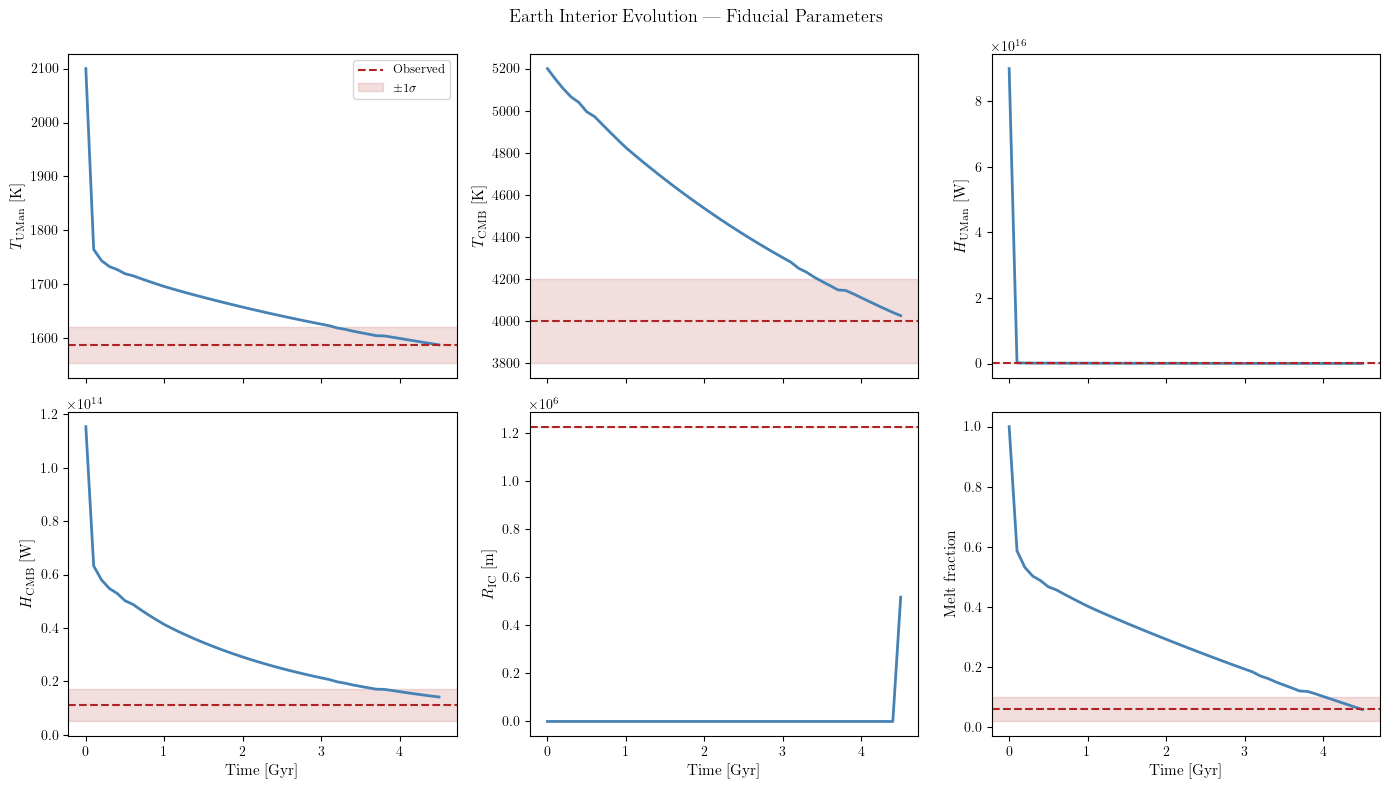


Final time recorded: 4.50 Gyr


In [9]:
# Run the evolution model to get time series
evol = vpm_evol.run_model(theta_fiducial, remove=True)

time_gyr = evol["Time"].to(u.Gyr).value

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.flatten()

# Data to plot: (key, label, observed mean, observed std, y-scale)
evol_keys = [
    ("final.earth.TUMan",    r"$T_{\rm UMan}$ [K]",       1587,              34,           "linear"),
    ("final.earth.TCMB",     r"$T_{\rm CMB}$ [K]",        4000,              200,          "linear"),
    ("final.earth.HflowUMan",r"$H_{\rm UMan}$ [W]",       38.0 * TW_TO_W,   3 * TW_TO_W,  "linear"),
    ("final.earth.HflowCMB", r"$H_{\rm CMB}$ [W]",        11.0 * TW_TO_W,   6 * TW_TO_W,  "linear"),
    ("final.earth.RIC",      r"$R_{\rm IC}$ [m]",          1224.1e3,          1e3,          "linear"),
    ("final.earth.FMeltUMan",r"Melt fraction",              0.06,              0.04,         "linear"),
]

for ax, (key, ylabel, obs_mean, obs_std, yscale) in zip(axes, evol_keys):
    yvals = evol[key]
    # Quantities (non-None units) need .value for matplotlib
    if hasattr(yvals, 'value'):
        yvals = yvals.value
    ax.plot(time_gyr, yvals, color="steelblue", lw=2)
    ax.axhline(obs_mean, color="firebrick", ls="--", lw=1.5, label="Observed")
    ax.axhspan(obs_mean - obs_std, obs_mean + obs_std,
               alpha=0.15, color="firebrick", label=r"$\pm1\sigma$")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yscale(yscale)

for ax in axes[3:]:
    ax.set_xlabel("Time [Gyr]", fontsize=11)

axes[0].legend(fontsize=9, loc="upper right")
fig.suptitle("Earth Interior Evolution — Fiducial Parameters", fontsize=13)
plt.tight_layout()
plt.show()
print(f"\nFinal time recorded: {time_gyr[-1]:.2f} Gyr")

## 4. Single Optimization Run

We minimize the **negative log-likelihood** using `scipy.optimize.minimize` with the
**Nelder-Mead** algorithm.

Nelder-Mead is a gradient-free simplex method — it does not require derivatives of the
objective function, which is important here because VPLanet is a black-box numerical code
with no analytical gradients.
The `adaptive=True` option scales the algorithm's step sizes to the problem dimensionality.

> **Why Nelder-Mead?** The Earth interior likelihood landscape is non-convex and potentially
> multi-modal (multiple local maxima), so we need a method that can explore broadly without
> getting stuck near the starting point. The next section addresses this more systematically
> with multi-start optimization.

> **Note:** If optimizer is failing to converge, try increasing ``maxiter`` 

In [10]:
neg_lnlike = lambda theta: -lnlike(theta, like_data)

# Start from the fiducial parameters for this single run
print("Running single optimization from fiducial starting point...")

result_single = scipy.optimize.minimize(
    neg_lnlike,
    x0=theta_fiducial,
    bounds=bounds.tolist(),
    method="nelder-mead",
    options={"maxiter": 200, "adaptive": True},
)

theta_opt_single = result_single.x
lnl_opt_single   = -result_single.fun

print(f"\nOptimization status: {'Converged' if result_single.success else 'Not converged'}")
print(f"Function evaluations: {result_single.nfev}")
print(f"\nLog-likelihood improvement: {lnl_fid:.2f} -> {lnl_opt_single:.2f}")
print(f"\nBest-fit parameters (single run):")
for label, val_fid, val_opt in zip(inlabels, theta_fiducial, theta_opt_single):
    print(f"  {label:35s}  fiducial={val_fid:.4g}  MLE={val_opt:.4g}")

Running single optimization from fiducial starting point...

Optimization status: Not converged
Function evaluations: 401

Log-likelihood improvement: -100798.23 -> -1.29

Best-fit parameters (single run):
  ${}^{40}\text{K}$ Mantle Power [W]   fiducial=3.616e+13  MLE=3.729e+13
  ${}^{40}\text{K}$ Core Power [W]     fiducial=3.386e+13  MLE=3.366e+13
  $T_{\rm man}$ [K]                    fiducial=3000  MLE=2977
  $T_{\rm core}$ [K]                   fiducial=6500  MLE=6368
  Erupt. Efficiency                    fiducial=0.1  MLE=0.09925
  $\Delta T_{\chi}$                    fiducial=0  MLE=0.0001465
  Visc. Reference                      fiducial=6e+07  MLE=6.025e+07
  Visc. Jump                           fiducial=2.4  MLE=2.325
  Act. Viscosity [m$^2$/s]             fiducial=3e+05  MLE=2.978e+05


## 5. Multi-Start MLE

A single optimization from one starting point may converge to a **local** maximum of the
likelihood rather than the global one. To mitigate this:

1. We draw `n_starts` random starting points uniformly from the prior bounds
2. We run a separate optimization from each starting point in **parallel**
3. We select the solution with the **highest log-likelihood** across all runs

This multi-start strategy increases confidence that we have found the global MLE.
The `analysis.py` script in this directory runs 100 optimizations on 32 cores;
here we use fewer starts to keep the notebook runtime manageable.

> **Practical tip:** For production runs, use at least 50–100 starts.
> Here we use 16 starts as a demonstration; increase `N_STARTS` as needed.

In [11]:
def uniform_prior_sampler(nsample, bounds):
    """Draw uniform samples within the prior bounds."""
    bounds = np.array(bounds)
    return np.random.uniform(bounds[:, 0], bounds[:, 1], size=(nsample, bounds.shape[0]))


def opt_parallel(x0):
    """Run a single Nelder-Mead optimization from starting point x0."""
    result = scipy.optimize.minimize(
        neg_lnlike,
        x0=x0,
        bounds=bounds.tolist(),
        method="nelder-mead",
        options={"maxiter": 200, "adaptive": True},
    )
    return result.x


N_STARTS = 16    # increase to 50–100 for more thorough exploration
N_CORES  = min(8, mp.cpu_count())

np.random.seed(42)
starting_points = uniform_prior_sampler(N_STARTS, bounds)

print(f"Multi-start MLE: {N_STARTS} starts on {N_CORES} cores")
print(f"Starting points shape: {starting_points.shape}")

Multi-start MLE: 16 starts on 8 cores
Starting points shape: (16, 9)


In [ ]:
print(f"Running {N_STARTS} optimizations in parallel...")

with mp.Pool(N_CORES) as pool:
    opt_results = list(tqdm(
        pool.imap(opt_parallel, starting_points),
        total=N_STARTS,
        desc="Optimizing",
    ))

print("\nDone. Evaluating log-likelihood at each solution...")

# Evaluate likelihood at each optimized solution
lnl_values = [lnlike(theta, like_data) for theta in opt_results]

print(f"Log-likelihood range: [{min(lnl_values):.2f}, {max(lnl_values):.2f}]")
print(f"Best log-likelihood:  {max(lnl_values):.2f}")

Running 16 optimizations in parallel...


Optimizing:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
# Build a DataFrame with all MLE results
param_keys = list(inparams.keys())
rows = []
for ii, (theta_opt, lnl) in enumerate(zip(opt_results, lnl_values)):
    row = {"run": ii, "lnlike": lnl}
    for key, val in zip(param_keys, theta_opt):
        row[key] = val
    rows.append(row)

df_mle = pd.DataFrame(rows)
df_mle.to_csv("mle_earth_results.csv", index=False)

print("MLE results saved to mle_earth_results.csv")
print(df_mle[["run", "lnlike"] + param_keys[:4]].to_string(index=False))

## 6. Analyzing the MLE Results

### 6.1 Best-Fit Parameters

The global MLE solution is the row with the highest log-likelihood value.
We compare the best-fit model outputs against the observed Earth values.

In [ ]:
# Identify the best solution
best_idx   = df_mle["lnlike"].idxmax()
theta_best = df_mle.loc[best_idx, param_keys].values.astype(float)
lnl_best   = df_mle.loc[best_idx, "lnlike"]

print(f"Best solution: run {best_idx}  |  ln L = {lnl_best:.2f}\n")
print(f"{'Parameter':<40}  {'Fiducial':>14}  {'MLE Best':>14}  {'Bounds':>20}")
print("-" * 95)
for label, key, fid, mle, (lo, hi) in zip(
        inlabels, param_keys, theta_fiducial, theta_best, bounds):
    print(f"  {label:<38}  {fid:14.4g}  {mle:14.4g}  [{lo:.3g}, {hi:.3g}]")

### 6.2 Model Outputs vs. Observations

We run the best-fit model and compare its predictions to the observed Earth values.
Residuals are expressed in units of the observational $1\sigma$ uncertainty.

In [ ]:
# Run best-fit model
print("Running best-fit model...")
mdl_best = vpm_final.run_model(theta_best, remove=True)

obs_means = like_data[:, 0]
obs_stds  = like_data[:, 1]
residuals_fid  = (mdl_fid  - obs_means) / obs_stds
residuals_best = (mdl_best - obs_means) / obs_stds

print(f"\nFiducial chi^2 = {-2*lnl_fid:.2f}")
print(f"Best-fit chi^2 = {-2*lnl_best:.2f}")
print(f"\n{'Observable':<14}  {'Observed':>14}  {'Fiducial':>14}  {'MLE':>14}  {'Res_fid':>9}  {'Res_mle':>9}")
print("-" * 82)
for label, obs, fid_m, best_m, r_fid, r_best in zip(
        outlabels, obs_means, mdl_fid, mdl_best, residuals_fid, residuals_best):
    print(f"  {label:<12s}  {obs:14.4g}  {fid_m:14.4g}  {best_m:14.4g}  {r_fid:9.2f}  {r_best:9.2f}")

In [ ]:
# Plot: residuals at fiducial vs. MLE best-fit
fig, ax = plt.subplots(figsize=(8, 5))

y = np.arange(len(outlabels))
ax.barh(y - 0.2, np.abs(residuals_fid),  height=0.35, color="steelblue", alpha=0.8,
        label="Fiducial")
ax.barh(y + 0.2, np.abs(residuals_best), height=0.35, color="darkorange", alpha=0.8,
        label="MLE best-fit")

ax.axvline(1, color="gray", ls="--", lw=1.2, label=r"$1\sigma$")
ax.axvline(2, color="gray", ls=":",  lw=1.2, label=r"$2\sigma$")

ax.set_yticks(y)
ax.set_yticklabels(outlabels, fontsize=11)
ax.set_xlabel(r"$|$Residual$|$ [$\sigma$]", fontsize=12)
ax.set_title("Model vs. Observed Earth — Normalized Residuals", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, max(np.abs(residuals_fid).max(), np.abs(residuals_best).max()) * 1.15)

plt.tight_layout()
plt.show()

### 6.3 Distribution of Log-Likelihood Values

The histogram shows the log-likelihood values across all `N_STARTS` optimization runs.
A well-converged multi-start run will show that many starts converge to similar values,
and the best solution stands out clearly.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df_mle["lnlike"], bins=12, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(lnl_best, color="firebrick", ls="--", lw=2, label=f"Best: {lnl_best:.1f}")
ax.axvline(lnl_fid,  color="darkorange", ls="-.", lw=2, label=f"Fiducial: {lnl_fid:.1f}")

ax.set_xlabel(r"Log-likelihood $\ln\mathcal{L}$", fontsize=12)
ax.set_ylabel("Number of runs", fontsize=12)
ax.set_title(f"MLE Results: {N_STARTS} random starts", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 6.4 Parameter Distribution Across MLE Solutions

Looking at the distribution of **all** MLE solutions (not just the best one) reveals
which parameters are tightly constrained by the data and which are poorly determined.

- **Narrow distributions** → the observable data strongly constrains that parameter
- **Broad/flat distributions** → the data is not very informative about that parameter
  (may indicate a degeneracy between parameters)

> **Note:** MLE scatter should not be confused with Bayesian posterior uncertainty.
> For a full characterisation of parameter uncertainties, use MCMC
> (see Tutorial 3: MCMC with Custom Likelihood).

In [ ]:
n_params = len(param_keys)
ncols = 3
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3 * nrows))
axes = axes.flatten()

for ii, (key, label) in enumerate(zip(param_keys, inlabels)):
    vals = df_mle[key].values
    axes[ii].hist(vals, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
    axes[ii].axvline(theta_best[ii], color="firebrick",  ls="--", lw=2, label="Best")
    axes[ii].axvline(theta_fiducial[ii], color="darkorange", ls="-.", lw=2, label="Fiducial")
    axes[ii].set_xlabel(label, fontsize=9)
    axes[ii].set_ylabel("Count", fontsize=9)
    if ii == 0:
        axes[ii].legend(fontsize=8)

# Hide unused subplots
for ii in range(n_params, len(axes)):
    axes[ii].set_visible(False)

fig.suptitle("Distribution of MLE Solutions Across Random Starts", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Step | Code |
|------|------|
| Define inparams and units | `inparams = {"earth.dTMan": u.K, ...}` |
| Set observational constraints | `like_data = np.array([(mean, std), ...])` |
| Initialize VplanetModel | `vpm_final = vpi.VplanetModel(inparams, outparams, ...)` |
| Define log-likelihood | `lnl = -0.5 * sum(((model - obs) / sigma)^2)` |
| Single optimization | `scipy.optimize.minimize(neg_lnlike, x0, bounds=bounds, method='nelder-mead')` |
| Multi-start MLE | `mp.Pool(N_CORES).imap(opt_parallel, starting_points)` |
| Select best solution | `theta_best = results[argmax(lnl_values)]` |

**Key takeaways:**

- The MLE approach identifies parameter combinations consistent with present-day Earth observations
- Multi-start optimization guards against local optima in a non-convex likelihood landscape
- Well-constrained observables (e.g. inner core radius from seismology) strongly pin certain parameters
- Poorly constrained observables (e.g. mantle viscosity) leave some parameters degenerate

**Next steps:**

- Run the `analysis.py` script in this directory for a larger-scale MLE (100 starts, 32 cores)
- Quantify parameter uncertainties with MCMC — see **Tutorial 3** in the `tutorials/` directory
- Compute the Fisher Information Matrix at the MLE to estimate parameter covariances
  (implemented in `analysis.py` using the `fischer` module)